# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [138]:
import pandas as pd
import requests
import bs4 as bs
import yfinance as yf
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import re
import html
import datetime
from scipy.stats import norm

pd.set_option("display.max_colwidth", None)


---
### Task #4 : Measuring media attention (1)

• Use the list of tickers gathered during last PC Lab (see the web-scrapping part) to compute the number of tweets about each stock

– e.g., AAPL: 36 tweets, 12 negative, 24 positive

In [139]:
# Loading the aggregated sentiment scores
df_aggregated_sentiments = pd.read_csv("final_aggregated_sentiments.csv")
df_aggregated_sentiments.sort_values(by="date", ascending=False).reset_index(drop=True)

,ticker,date,n_tweets,sent_index
0,AMZN,2020-07-22,706,0.2
1,BAC,2020-07-22,51,0.1
2,NFLX,2020-07-22,37,-0.1
3,WMT,2020-07-21,27,-0.2
4,NFLX,2020-07-21,354,-0.2
...,...,...,...,...
52457,AAPL,2009-07-29,1,1.0
52458,BAC,2009-07-13,1,1.0
52459,AAPL,2009-07-13,3,0.0
52460,NFLX,2009-07-13,1,1.0


In [140]:
df_aggregated_sentiments.describe()

,n_tweets,sent_index
count,52462.000000,52462.000000
mean,88.599005,0.138553
std,289.331361,0.289658
min,1.000000,-1.000000
25%,5.000000,0.000000
50%,17.000000,0.100000
75%,60.000000,0.300000
max,14971.000000,1.000000


#### Rank the stocks by their amount of total media attention, or, alternatively : positive and negative media attention, level of disagreement (dispersion), etc.

In [141]:
attention_rank = (
    df_aggregated_sentiments.groupby("ticker")["n_tweets"]
    .sum()
    .sort_values(ascending=False)
)
attention_rank

ticker
TSLA     1514647
AAPL     1101533
NFLX      585224
AMZN      397958
DIS       212834
BAC       147407
GOOG      124147
GOOGL      99132
FB         96800
T          62712
HD         46981
VZ         45889
V          44606
JNJ        34615
ADBE       33014
BRK.B      30124
PG         29625
UNH        14428
INTC       13920
WMT        12485
Name: n_tweets, dtype: int64

The Top 5 stocks with the greatest number of tweets over the researched period (after having applied constraints to the length of the tweet) are: 
- Tesla, 
- Apple,
- Netflix,
- Amazon and
- Walt Disney Co

In [142]:
# total tweets per ticker
total_per_ticker = df_aggregated_sentiments.groupby("ticker")["n_tweets"].sum()

# positive and negative tweets per ticker
pos_per_ticker = df_aggregated_sentiments.loc[df_aggregated_sentiments["sent_index"] > 0].groupby("ticker")["n_tweets"].sum()
neg_per_ticker = df_aggregated_sentiments.loc[df_aggregated_sentiments["sent_index"] < 0].groupby("ticker")["n_tweets"].sum()

# normalize: share of positive/negative
pos_share = (pos_per_ticker / total_per_ticker).fillna(0).sort_values(ascending=False)
neg_share = (neg_per_ticker / total_per_ticker).fillna(0).sort_values(ascending=False)

print("Top 10 by *share* of positive attention:\n", pos_share.head(10))
print("\nTop 10 by *share* of negative attention:\n", neg_share.head(10))


Top 10 by *share* of positive attention:
 ticker
V        0.715061
GOOG     0.709739
ADBE     0.704610
GOOGL    0.697040
VZ       0.648325
INTC     0.635991
JNJ      0.625856
HD       0.614142
AMZN     0.610466
WMT      0.608971
Name: n_tweets, dtype: float64

Top 10 by *share* of negative attention:
 ticker
TSLA     0.443773
NFLX     0.350204
FB       0.299370
BAC      0.279695
DIS      0.267373
AAPL     0.265570
AMZN     0.242485
BRK.B    0.230248
T        0.206595
HD       0.197931
Name: n_tweets, dtype: float64


Companies with the **highest positive attention** are those often associated with **strong brands, innovation** or c**onsistent financial performance**. On the other hand, companies that lead the **negative sentiment** rankings often spark polarizing opinions due to **leadership controversies, aggressive strategies** or **volatile performance**.

In [143]:
disagreement_rank = (
    df_aggregated_sentiments.groupby("ticker")["sent_index"]
    .std()  # high std = more dispersion in daily sentiment
    .sort_values(ascending=False)
)

disagreement_rank

ticker
UNH      0.355130
WMT      0.349057
INTC     0.339239
ADBE     0.337469
HD       0.315216
VZ       0.310314
BRK.B    0.309564
FB       0.307352
DIS      0.299169
JNJ      0.290081
PG       0.289719
TSLA     0.289432
T        0.286627
V        0.268366
NFLX     0.251349
BAC      0.248856
AAPL     0.242661
AMZN     0.242657
GOOGL    0.233982
GOOG     0.230000
Name: sent_index, dtype: float64

With the contraints applied to the tweets (the length of the tweet and the random sampling of 10 tweets per day per stock), the **stocks with the greatest level of disagreement**, indicated by the greatest dispersion of the sentiment score, are:
  - UnitedHealth Group Inc
  - Walmart Inc
  - Intel Corp
  - Adobe Inc
  - Home Depot Inc

The high dispersion in sentiment scores of those comapnies can be attributed to the **diversity of their stakeholders** and the **nature of the industries**. Firms like UnitedHealth and Walmart operate in sectors that directly affect **broad groups of people**, while technology companies such as Intel and Adobe are subject to polarized reactions due to **competitive dynamics** and the **pace of innovation** which can spark both enthusiasm and skepticism. In addition, strongly **consumer-facing businesses** like Walmart and Home Depot, with customer experiences, pricing and service quality, often generate both praise and criticism. These factors explain why such companies exhibit greater disagreement in sentiment.

**Media Attention Measure**

$$
Media\_Attention\_Score = \log(1 + n\_tweets) \times (sent\_index + 1)/2
$$

**Logarithm transformation** controls for diminishing marginal effect of tweet volume, while smoothing the dynamics. 

**Normalized sentiment index** maps this score from [-1,1] --> [0,1] where 0.5 is now neutral.

In [144]:
df_aggregated_sentiments["Media_Attention_Score"] = (
    np.log(1 + df_aggregated_sentiments["n_tweets"]) * (df_aggregated_sentiments["sent_index"] + 1)/2
)

In [145]:
df_aggregated_sentiments.head()

,ticker,date,n_tweets,sent_index,Media_Attention_Score
0,AAPL,2009-07-10,1,0.0,0.346574
1,AAPL,2009-07-13,3,0.0,0.693147
2,AAPL,2009-07-29,1,1.0,0.693147
3,AAPL,2009-07-30,1,0.0,0.346574
4,AAPL,2009-07-31,2,-0.5,0.274653


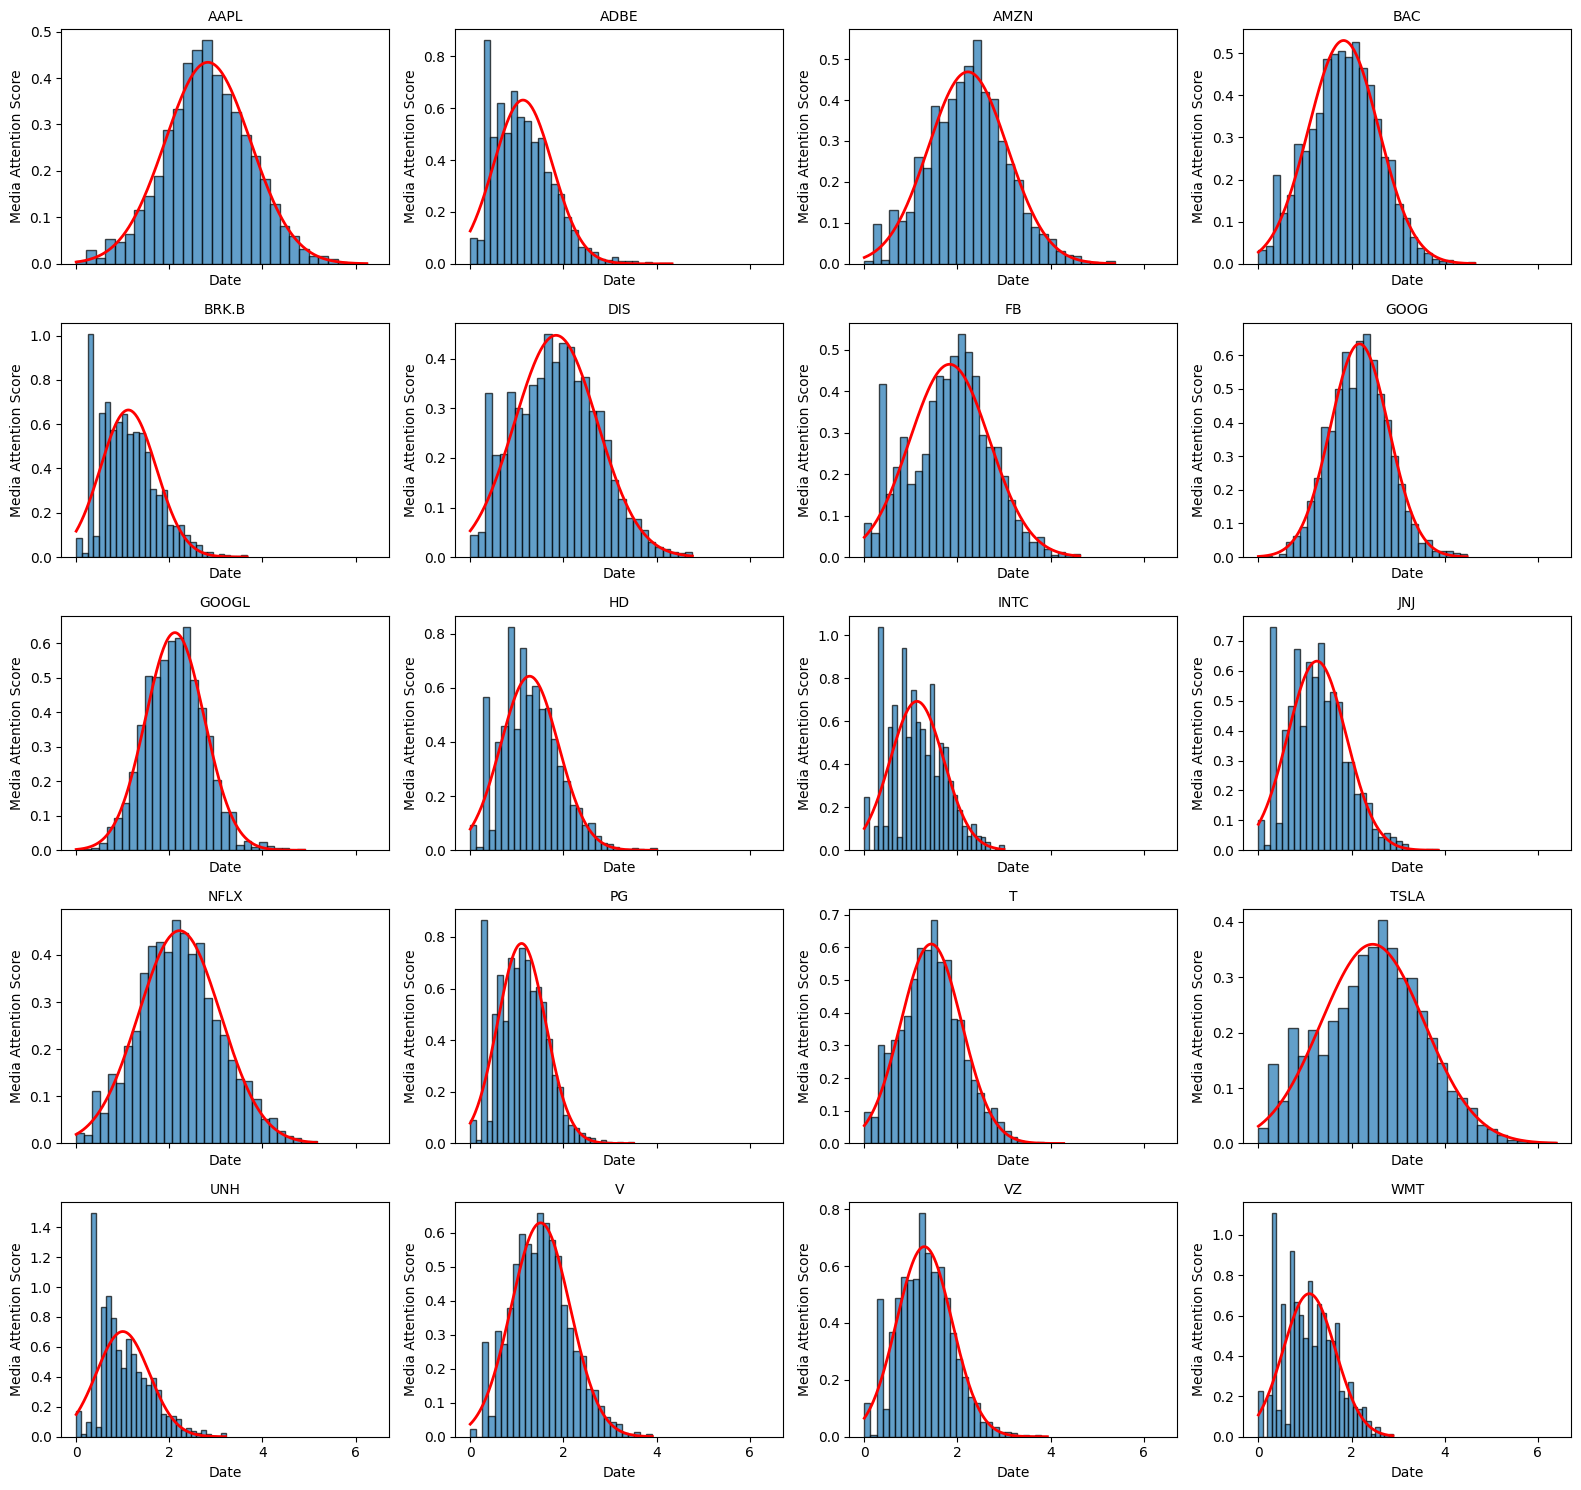

In [146]:
tickers = df_aggregated_sentiments["ticker"].unique()

# Grid size for subplots
n_cols = 4
n_rows = int(np.ceil(len(tickers) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows), sharex=True, sharey=False)
axes = axes.flatten()

for i, tkr in enumerate(sorted(tickers)):
    sub = df_aggregated_sentiments[df_aggregated_sentiments["ticker"] == tkr].sort_values("date")
    ax = axes[i]
    
    ax.hist(sub["Media_Attention_Score"], bins=30, alpha=0.7, edgecolor="black", density=True)
    
    # Fitting normal distribution
    data = sub["Media_Attention_Score"]
    mu, sigma = np.mean(data), np.std(data)
    x = np.linspace(data.min(), data.max(), 200)
    pdf = norm.pdf(x, mu, sigma)

    axes[i].plot(x, pdf, "r-", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
    ax.set_title(tkr, fontsize=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Media Attention Score")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Many stocks show **heavy right skewness** - most days have lower attention, but there are occasional spikes.
- Some stocks such as **AAPL, AMZN, NFLX, TSLA, GOOG and BAC** have distributions that look **more symmetric and bell-shaped**, though still slightly skewed.
- Tech companies such as **AAPL, AMZN, NFLX and TSLA** show **higher attention scores**.

### Web-scrapping - Yahoo Finance data

In [147]:
tickers = df_aggregated_sentiments['ticker'].unique()
tickers = list(tickers) + ["^GSPC"] # S&P 500
tickers = [s.replace('.','-') for s in tickers]
print(tickers)

['AAPL', 'ADBE', 'AMZN', 'BAC', 'BRK-B', 'DIS', 'FB', 'GOOG', 'GOOGL', 'HD', 'INTC', 'JNJ', 'NFLX', 'PG', 'T', 'TSLA', 'UNH', 'V', 'VZ', 'WMT', '^GSPC']


In [148]:
start = datetime.datetime(2009, 7, 9)
data = yf.download(tickers, start=start, end=None)

C:\Users\lasko\AppData\Local\Temp\ipykernel_31028\4136676933.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  21 of 21 completed


In [149]:
data.head()

Price          Close                                                          \
Ticker          AAPL       ADBE    AMZN        BAC      BRK-B        DIS  FB   
Date                                                                           
2009-07-09  4.093543  27.420000  3.9050   9.320661  55.419998  19.082453 NaN   
2009-07-10  4.158388  27.580000  3.8815   9.250579  54.900002  18.980814 NaN   
2009-07-13  4.273063  28.370001  4.0735  10.114901  56.560001  19.226435 NaN   
2009-07-14  4.270961  28.299999  4.0975  10.052608  57.400002  19.573694 NaN   
2009-07-15  4.409355  29.850000  4.2275  10.449729  58.799999  20.395271 NaN   

Price                                        ...    Volume            \
Ticker           GOOG      GOOGL         HD  ...       JNJ      NFLX   
Date                                         ...                       
2009-07-09  10.151966  10.199671  15.327244  ...  11324800  12084100   
2009-07-10  10.251162  10.299335  15.219114  ...  13661800   5254900   
2009-07-13  10.496062  10.545384  15.617835  ...  13564900  29690500   
2009-07-14  10.505711  10.555079  16.003059  ...  20433700  13967800   
2009-07-15  10.839169  10.890104  16.273367  ...  12986200   9424800   

Price                                                                        \
Ticker            PG         T TSLA       UNH         V        VZ       WMT   
Date                                                                          
2009-07-09  11648100  33712747  NaN   8967800  26616400  15224190  45369600   
2009-07-10   9267400  28892460  NaN   5621200  16654800  13454364  47913300   
2009-07-13  12289100  34067447  NaN   5801600  30640000  13777003  48102900   
2009-07-14  12817300  35882783  NaN   9708400  13291200  13648737  40399200   
2009-07-15  15161300  34004424  NaN  12532300  36492400  19160263  56225100   

Price                   
Ticker           ^GSPC  
Date                    
2009-07-09  4347170000  
2009-07-10  3912080000  
2009-07-13  4499440000  
2009-07-14  4149030000  
2009-07-15  5238830000  

[5 rows x 105 columns]

In [150]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,ADBE,AMZN,BAC,BRK-B,DIS,FB,GOOG,GOOGL,HD,...,JNJ,NFLX,PG,T,TSLA,UNH,V,VZ,WMT,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2009-07-09,4.093543,27.420000,3.9050,9.320661,55.419998,19.082453,NaN,10.151966,10.199671,15.327244,...,35.086258,5.707143,32.660568,5.528626,NaN,19.587214,13.456742,11.847848,11.393739,882.679993
2009-07-10,4.158388,27.580000,3.8815,9.250579,54.900002,18.980814,NaN,10.251162,10.299335,15.219114,...,35.234806,5.724286,32.542168,5.542816,NaN,19.375160,13.327608,11.839575,11.272882,879.130005
2009-07-13,4.273063,28.370001,4.0735,10.114901,56.560001,19.226435,NaN,10.496062,10.545384,15.617835,...,35.723743,6.027143,33.015789,5.620852,NaN,19.642187,13.436703,12.017460,11.334496,901.049988
2009-07-14,4.270961,28.299999,4.0975,10.052608,57.400002,19.573694,NaN,10.505711,10.555079,16.003059,...,36.039383,6.185714,33.364758,5.545182,NaN,19.453697,13.423347,11.976097,11.405589,905.840027
2009-07-15,4.409355,29.850000,4.2275,10.449729,58.799999,20.395271,NaN,10.839169,10.890104,16.273367,...,36.491196,6.344286,34.056488,5.668145,NaN,19.563650,13.948792,12.137430,11.505117,932.679993


In [151]:
returns = close_prices.pct_change()
returns = returns.iloc[1:]
returns.head()

Ticker,AAPL,ADBE,AMZN,BAC,BRK-B,DIS,FB,GOOG,GOOGL,HD,...,JNJ,NFLX,PG,T,TSLA,UNH,V,VZ,WMT,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2009-07-10,0.015841,0.005835,-0.006018,-0.007519,-0.009383,-0.005326,NaN,0.009771,0.009771,-0.007055,...,0.004234,0.003004,-0.003625,0.002567,NaN,-0.010826,-0.009596,-0.000698,-0.010607,-0.004022
2009-07-13,0.027577,0.028644,0.049465,0.093434,0.030237,0.012940,NaN,0.023890,0.023890,0.026199,...,0.013877,0.052907,0.014554,0.014079,NaN,0.013782,0.008186,0.015025,0.005466,0.024934
2009-07-14,-0.000492,-0.002467,0.005892,-0.006158,0.014851,0.018062,NaN,0.000919,0.000919,0.024666,...,0.008836,0.026309,0.010570,-0.013462,NaN,-0.009596,-0.000994,-0.003442,0.006272,0.005316
2009-07-15,0.032403,0.054770,0.031727,0.039504,0.024390,0.041974,NaN,0.031741,0.031741,0.016891,...,0.012537,0.025635,0.020732,0.022175,NaN,0.005652,0.039144,0.013471,0.008726,0.029630
2009-07-16,0.004357,0.034171,0.018451,-0.018629,-0.005782,0.029485,NaN,0.010110,0.010110,0.013289,...,0.004918,-0.006305,0.010247,-0.010847,NaN,0.013649,0.028093,0.005453,-0.000824,0.008642


In [152]:
returns_long = returns.stack().reset_index()
returns_long.columns = ["date", "ticker", "return"]
returns_long.head()

,date,ticker,return
0,2009-07-10,AAPL,0.015841
1,2009-07-10,ADBE,0.005835
2,2009-07-10,AMZN,-0.006018
3,2009-07-10,BAC,-0.007519
4,2009-07-10,BRK-B,-0.009383


In [153]:
returns_long["date"] = pd.to_datetime(returns_long["date"])
df_aggregated_sentiments["date"] = pd.to_datetime(df_aggregated_sentiments["date"])

### Merging returns and aggregated sentiments datasets

In [154]:
merged_df = pd.merge(
    df_aggregated_sentiments,
    returns_long,
    on=["ticker", "date"],
    how="inner"
)

merged_df = merged_df.sort_values(by="date", ascending=True).reset_index(drop=True)
merged_df.head()

,ticker,date,n_tweets,sent_index,Media_Attention_Score,return
0,AAPL,2009-07-10,1,0.0,0.346574,0.015841
1,AAPL,2009-07-13,3,0.0,0.693147,0.027577
2,BAC,2009-07-13,1,1.0,0.693147,0.093434
3,NFLX,2009-07-13,1,1.0,0.693147,0.052907
4,AAPL,2009-07-29,1,1.0,0.693147,0.000188


#### • Do you see a correlation between media attention g and stock returns?

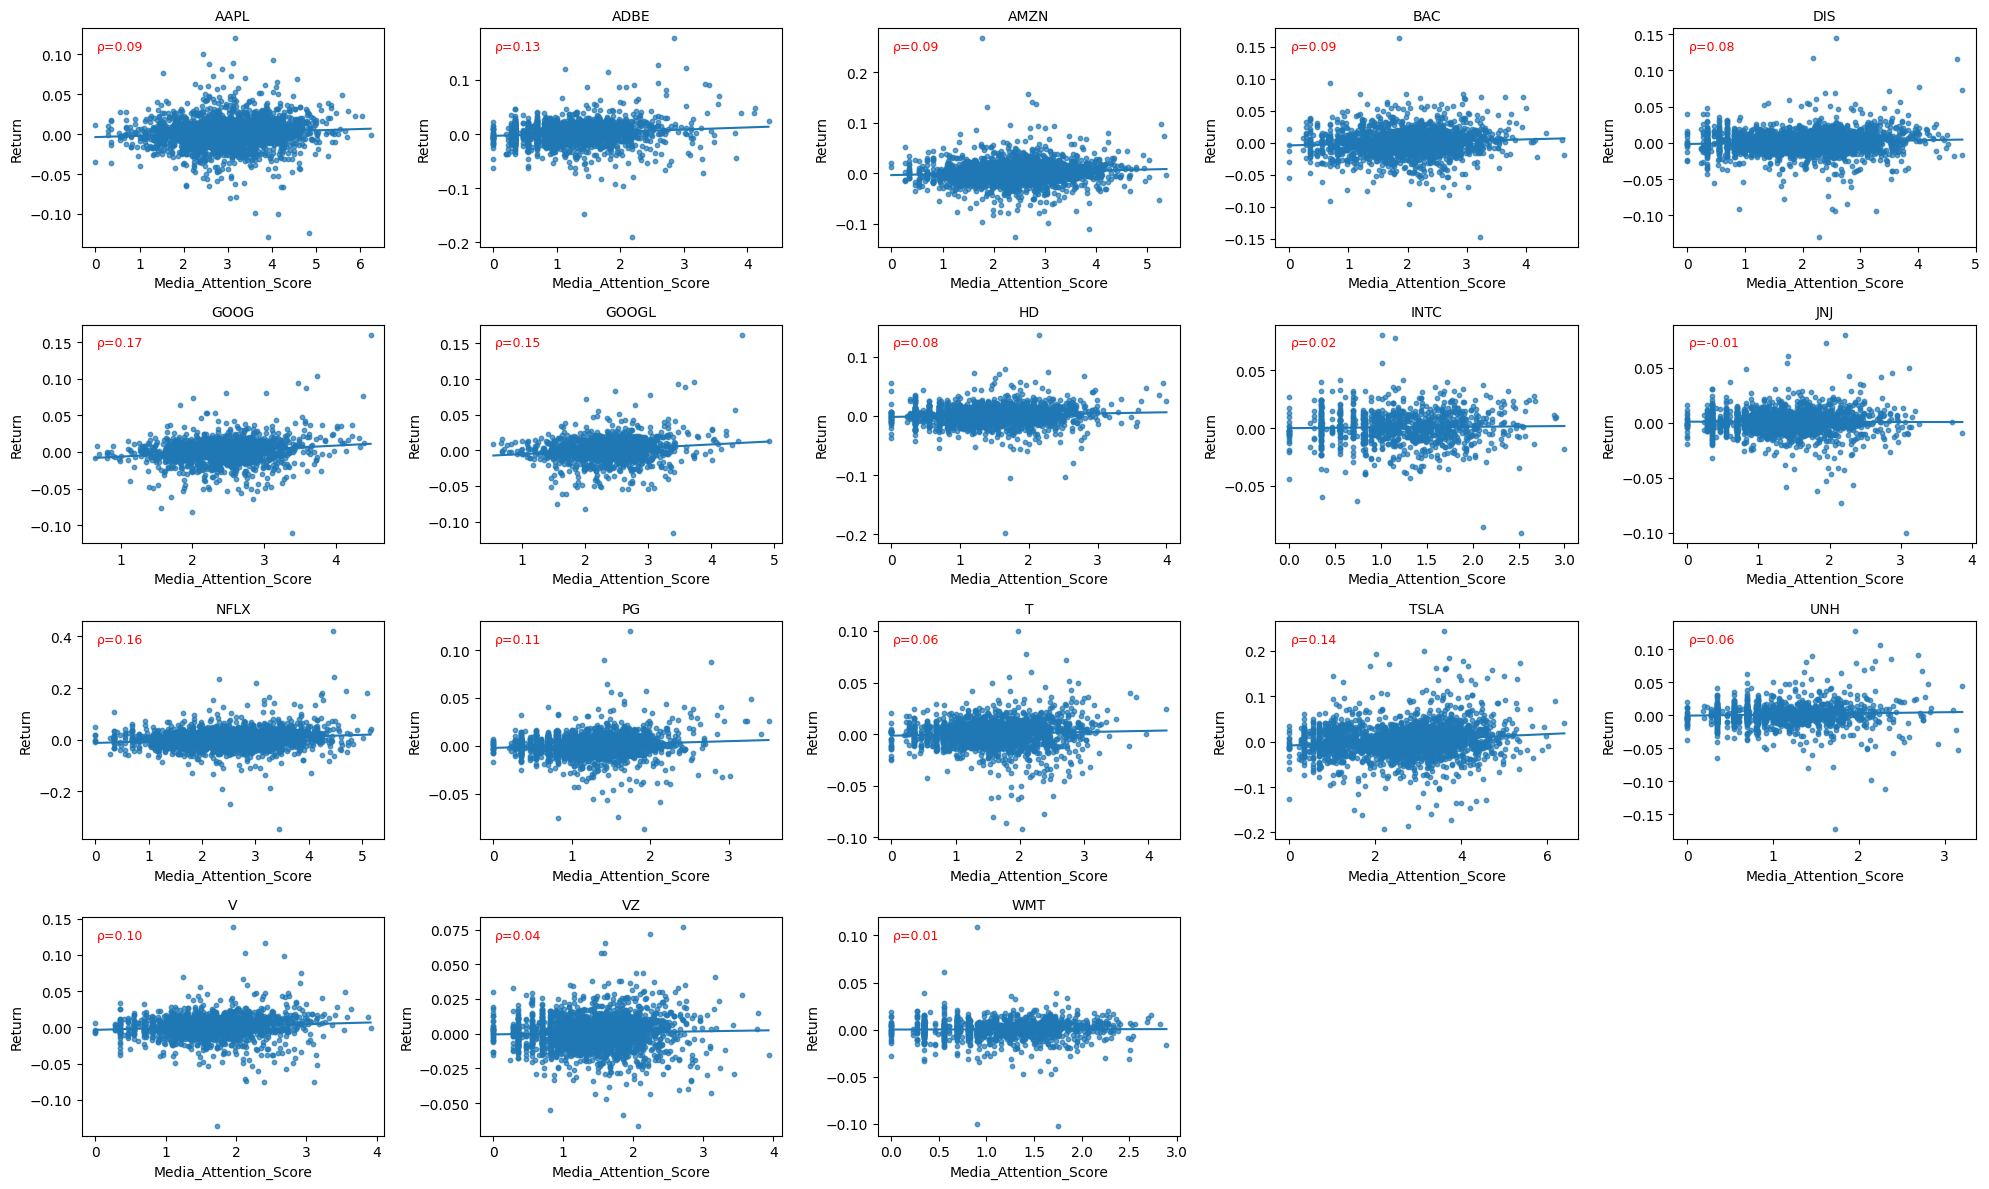

In [ ]:
tickers = merged_df["ticker"].dropna().unique()
n_tickers = len(tickers)

# grid size
n_cols = int(np.ceil(np.sqrt(n_tickers)))
n_rows = int(np.ceil(n_tickers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=False, sharey=False)
axes = axes.flatten()

for i, tkr in enumerate(sorted(tickers)):
    sub = merged_df[merged_df["ticker"] == tkr]
    ax = axes[i]
    
    ax.scatter(sub["Media_Attention_Score"], sub["return"], s=10, alpha=0.7)
    
    # regression line
    if len(sub) > 1:
        try:
            m, b = np.polyfit(sub["Media_Attention_Score"], sub["return"], 1)
            x_line = np.linspace(sub["Media_Attention_Score"].min(), sub["Media_Attention_Score"].max(), 100)
            ax.plot(x_line, m*x_line + b, linewidth=1.5)
        except:
            pass

    ax.set_title(tkr, fontsize=10)
    ax.set_xlabel("Media_Attention_Score")
    ax.set_ylabel("Return")

    # Correlation
    if len(sub) > 1:
        corr = sub["Media_Attention_Score"].corr(sub["return"])
        ax.text(0.05, 0.9, f"ρ={corr:.2f}", transform=ax.transAxes,
                fontsize=9, color="red", ha="left")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- For most tickers, the scatter is very “cloud-like” with **no strong slope**. 
- Almost all correlations are positive, although weak. This could mean that **higher attention very slightly coincides with positive returns** — but the effect is economically small.
- On **high-attention days**, the **spread of returns widens**, but the correlation with the mean return remains weak.

#### • If yes, could Twitter attention is likely to be a good factor?

#### Create 10 portfolios based on your preferred measure of media attention

<span style="color:red">This is incorrect!!</span>

Because some stocks did not receive any comments on certain days, their sentiment scores are missing and thus excluded from the dataset. To ensure that all stocks are consistently included in the portfolio construction, we assume that missing values correspond to a **neutral sentiment score** of 0.

In [ ]:
# new_df = pd.read_csv('C:/Users/lasko/Documents/Bocconi/3rd_Semester/Finance with Big Data/PC_Lab_3/final_disaggregated_sentiments.csv')

In [ ]:
# new_df["datetime"] = pd.to_datetime(new_df["datetime"])

# # Extract just the date (drops hours/mins/seconds)
# new_df["date"] = new_df["datetime"].dt.date

# # Count tweets per symbol per day
# tweet_counts = (
#     new_df.groupby(["symbol", "date"])
#           .size()  # counts rows (tweets)
#           .reset_index(name="n_tweets")
# )

# tweet_counts.head()

,symbol,date,n_tweets
0,AAPL,2009-07-10,1
1,AAPL,2009-07-13,3
2,AAPL,2009-07-29,1
3,AAPL,2009-07-30,1
4,AAPL,2009-07-31,2


In [ ]:
# new_df["date"] = pd.to_datetime(new_df["date"])
# merged_df["date"] = pd.to_datetime(merged_df["date"])

In [ ]:
# final_df = pd.merge(
#     new_df,
#     merged_df,
#     on=["ticker", "date"],
#     how="left"
# )
# final_df = final_df[["ticker", "date", "return", "Media_Attention_Score", "sent_index", "n_tweets"]]
# final_df.head()

,ticker,date,return,Media_Attention_Score,sent_index,n_tweets
0,INTC,2009-09-16,0.005115,0.823959,0.5,2.0
1,INTC,2009-09-16,0.005115,0.823959,0.5,2.0
2,INTC,2009-09-22,-0.000511,0.693147,1.0,1.0
3,INTC,2009-09-29,-0.013171,0.000000,-1.0,1.0
4,INTC,2009-10-08,0.006583,0.274653,-0.5,2.0


In [ ]:
# missing_percentages = (
#     final_df.groupby("ticker")["sent_index"]
#       .apply(lambda x: x.isna().mean() * 100)
#       .reset_index(name="missing_pct")
# )

# missing_percentages

,ticker,missing_pct
0,AAPL,25.953384
1,ADBE,17.918001
2,AMZN,24.413675
3,BAC,23.542553
4,BRK.B,100.000000
5,DIS,25.516106
6,FB,100.000000
7,GOOG,29.274978
8,GOOGL,28.136400
9,HD,18.426276


<!-- Setting the **Sentiment Score** to neutral for stocks not mentioned on a specific day: -->

In [ ]:
# final_df['sent_index'].isna().sum()

np.int64(114508)

In [ ]:
# df_aggregated_sentiments["rank"] = df_aggregated_sentiments.groupby("date")["Media_Attention_Score"] \
#     .rank(method="first", ascending=False)

In [ ]:
# df_aggregated_sentiments["portfolio"] = df_aggregated_sentiments.groupby("date")["Media_Attention_Score"] \
#     .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)

In [ ]:
# portfolios = df_aggregated_sentiments.groupby(["date", "portfolio"])["ticker"].apply(list).reset_index()
# print(portfolios)

             date  portfolio     ticker
0      2009-08-30        1.0      [BAC]
1      2009-08-30       10.0     [AAPL]
2      2009-09-01        1.0  [DIS, FB]
3      2009-09-01        5.0     [AAPL]
4      2009-09-02        1.0     [NFLX]
...           ...        ...        ...
33021  2020-07-21        9.0      [JNJ]
33022  2020-07-21       10.0     [AMZN]
33023  2020-07-22        1.0     [NFLX]
33024  2020-07-22        5.0      [BAC]
33025  2020-07-22       10.0     [AMZN]

[33026 rows x 3 columns]


#### • Do you see a correlation between media attention g and stock returns?

#### • If yes, could Twitter attention is likely to be a good factor?

#### • Optional : same, but use FF-5 factors to purge returns from what a traditional model predicts, and plot media attention vs. erros

In [158]:
factors_df = pd.read_csv(
    "F-F_Research_Data_5_Factors_2x3_daily.csv",
    skiprows=3
)
factors_df.head()

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
4,19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01


#### Download the Fama–French 5 factors (Mkt-RF, SMB, HML, RMW, CMA, and RF) from Ken French’s Data Library

#### • Regress the stock’s excess returns on these five factors

####  Save the residuals from this regression. These represent the component of returns unexplained by traditional risk factors (abnormal returns).

#### • Redo same plot (see previous slide), but residuals vs. media attention.